# Analise topografica

## Imports

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import os
import gcsfs
import tempfile
import geopandas as gpd
from dotenv import find_dotenv, load_dotenv
from rasterio import plot as rplt

## Paths

In [2]:
dotenv_path = find_dotenv()
load_dotenv(dotenv_path)
project_root = os.path.dirname(dotenv_path)
KEY_PATH_RELATIVE = os.getenv("GOOGLE_APPLICATION_CREDENTIALS")
if KEY_PATH_RELATIVE:
    KEY_PATH_ABSOLUTE = os.path.join(project_root, KEY_PATH_RELATIVE)
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = KEY_PATH_ABSOLUTE
    print(f"Credenciais carregadas com sucesso de: {KEY_PATH_ABSOLUTE}")
else:
    print("Aviso: GOOGLE_APPLICATION_CREDENTIALS não encontrada no .env")

BUCKET_NAME = os.getenv("GCS_BUCKET_NAME")
PROJECT_ID = os.getenv("GCP_PROJECT_ID")
SLOPE_PATH = f"gs://{BUCKET_NAME}/raw/topography/declividade_brasil_srtm_1km.tif"
STATES_PATH = f"gs://{BUCKET_NAME}/raw/state_lines/BR_UF_2024.shp"
SLOPE_MASK_OUTPUT_PATH = (
    f"gs://{BUCKET_NAME}/processed/mascara_declividade_maior_5graus.tif"
)

Credenciais carregadas com sucesso de: g:\BackupC\Faculdade\UFRJ\TCC\analise-geografica-energia-solar-brasil\.secrets/tcc-usinas-solares-brasil-29b2750a20f8.json


## Carregamento de Dados

In [3]:
with rasterio.open(SLOPE_PATH) as slope_raster:
    print("Raster de Declividade carregado com sucesso do GCS!")
    print(
        f"CRS: {slope_raster.crs} | Dimensões: {slope_raster.width}x{slope_raster.height}"
    )

    slope_degrees = slope_raster.read(1)

    profile = slope_raster.profile

Raster de Declividade carregado com sucesso do GCS!
CRS: EPSG:4326 | Dimensões: 5026x4345


## Máscara de exclusão de declividade

Máscara para áreas com declividade > 5 graus criada.
Carregando limites estaduais de: gs://tcc-usinas-solares-brasil-dados/raw/state_lines/BR_UF_2024.shp


g:\BackupC\Faculdade\UFRJ\TCC\analise-geografica-energia-solar-brasil\.venv\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver ESRI Shapefile does not support open option FS
  return ogr_read(


Limites estaduais carregados com sucesso.


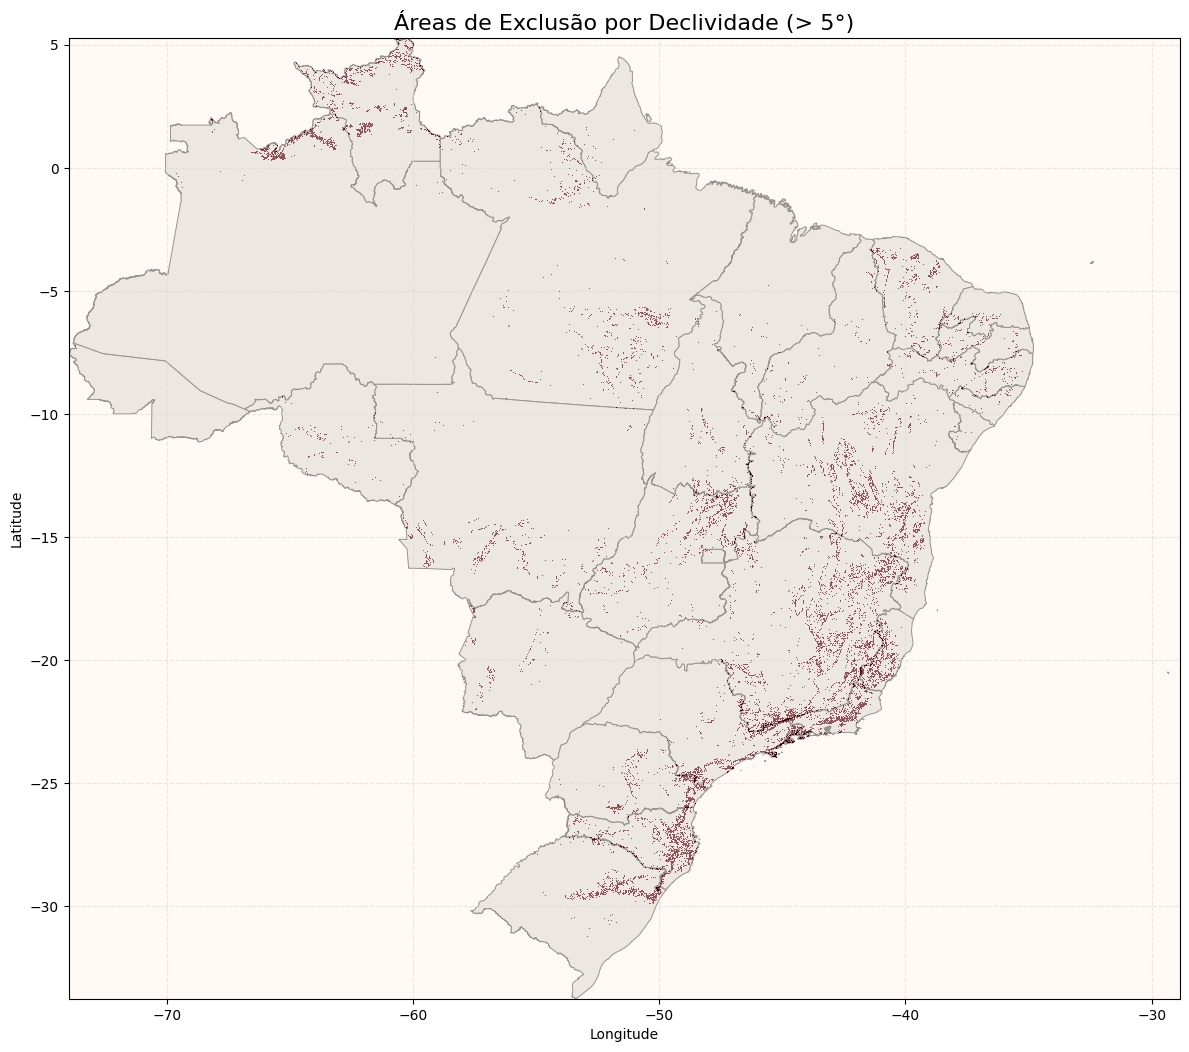

In [ ]:
SLOPE_THRESHOLD_DEGREES = 5
steep_areas_mask = slope_degrees > SLOPE_THRESHOLD_DEGREES
print(f"Máscara para áreas com declividade > {SLOPE_THRESHOLD_DEGREES} graus criada.")

br_gdf = None
try:
    fs = gcsfs.GCSFileSystem(project=PROJECT_ID)

    print(f"Carregando limites estaduais de: {STATES_PATH}")
    br_gdf = gpd.read_file(STATES_PATH, fs=fs)
    print("Limites estaduais carregados com sucesso.")
except Exception as e:
    print(
        "AVISO: Não foi possível carregar o contorno dos estados do Brasil. O mapa será gerado sem ele."
    )
    print(f"Erro: {e}")

if "steep_areas_mask" in locals():
    try:
        with fs.open(SLOPE_PATH, "rb") as f:
            with rasterio.open(f) as src:
                extent = rplt.plotting_extent(src)
    except Exception as e:
        print(f"ERRO: Não foi possível obter a extensão: {e}")
        extent = None

    # Plotar o mapa
    fig, ax = plt.subplots(figsize=(12, 12))

    if br_gdf is not None:
        br_gdf.plot(
            ax=ax, color="lightgray", edgecolor="black", linewidth=0.7, zorder=1
        )

    if extent is not None:
        plt.imshow(
            steep_areas_mask,
            cmap="Reds",
            extent=extent,
            interpolation="none",
            alpha=0.6,
            zorder=2,
        )

    ax.set_title(
        f"Áreas de Exclusão por Declividade (> {SLOPE_THRESHOLD_DEGREES}°)", fontsize=16
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, linestyle="--", alpha=0.6)

    if br_gdf is not None:
        ax.set_xlim(br_gdf.total_bounds[0], br_gdf.total_bounds[2])
        ax.set_ylim(br_gdf.total_bounds[1], br_gdf.total_bounds[3])

    plt.tight_layout()
    plt.show()

## Exportação dos dados

In [ ]:
if "steep_areas_mask" in locals():
    print(
        f"Verificando se o arquivo de máscara já existe em: gs://{SLOPE_MASK_OUTPUT_PATH}..."
    )

    fs = gcsfs.GCSFileSystem(project=PROJECT_ID)

    if fs.exists(SLOPE_MASK_OUTPUT_PATH):
        print("Arquivo de máscara já existe. Pulando etapa de salvamento.")
    else:
        with tempfile.NamedTemporaryFile(suffix=".tif", delete=False) as tmp:
            local_temp_path = tmp.name

        try:
            print(f"Salvando máscara temporariamente em: {local_temp_path}")

            profile.update(dtype=rasterio.uint8, count=1, compress="lzw", nodata=0)

            with rasterio.open(local_temp_path, "w", **profile) as dst:
                dst.write(steep_areas_mask.astype(rasterio.uint8), 1)

            print(f"Iniciando upload para: gs://{SLOPE_MASK_OUTPUT_PATH}")
            fs.upload(local_temp_path, SLOPE_MASK_OUTPUT_PATH)

            print("✅ Máscara de declividade salva com sucesso no GCS.")

        except Exception as e:
            print(
                f"❌ Ocorreu um erro durante o processo de salvar e fazer upload: {e}"
            )

        finally:
            if os.path.exists(local_temp_path):
                os.remove(local_temp_path)
                print(f"Arquivo temporário {local_temp_path} removido.")

Verificando se o arquivo de máscara já existe em: gs://gs://tcc-usinas-solares-brasil-dados/processed/mascara_declividade_maior_5graus.tif...
Salvando máscara temporariamente em: C:\Users\JPMar\AppData\Local\Temp\tmpv3lzryxy.tif
Iniciando upload para: gs://gs://tcc-usinas-solares-brasil-dados/processed/mascara_declividade_maior_5graus.tif
✅ Máscara de declividade salva com sucesso no GCS.
Arquivo temporário C:\Users\JPMar\AppData\Local\Temp\tmpv3lzryxy.tif removido.
